# PLN — Bag of Words (BoW) em Tweets #edtwt

Neste notebook, exploramos a representação **Bag of Words (BoW)**, uma das formas mais simples de vetorização textual.

O BoW conta a frequência bruta de cada termo em cada documento, gerando uma matriz documento-termo. Embora simples, essa representação serve como **baseline** para compararmos com TF-IDF, Word2Vec e BERT.

O pipeline inclui:
1. **Construção** da matriz BoW com `CountVectorizer` do scikit-learn sobre o texto normalizado.
2. **Diagnóstico** da distribuição de similaridade (com e sem centralização).
3. **Heatmap** interativo de similaridade cosseno (amostra).
4. **Clusterização** com KMeans sobre os vetores BoW.
5. **Visualização 2D/3D** via PCA e t-SNE.
6. **Comparação** direta entre BoW e TF-IDF no mesmo subconjunto.

---

In [13]:
%pip install scikit-learn plotly seaborn matplotlib pandas numpy --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import os
import json
import ast
import warnings
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

seed = 42

## Carregamento dos Dados

Utilizamos o `entrega_2.csv`, que contém os tweets já processados com tokenização, remoção de stopwords, stemming e normalização via regex.
A coluna `normalizacao_re` contém o texto normalizado e pronto para vetorização.

Também carregamos o JSON de metadados do TF-IDF (para referência dos hiperparâmetros e comparação posterior).

In [15]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2.csv')
json_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2_tfidf_features.json')

for p in [csv_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Arquivo nao encontrado: {p}')

df = pd.read_csv(csv_path)
print(f'Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas')
print(f'Colunas relevantes: text, normalizacao_re, features_tfidf_sklearn')

Dataset: 2815 tweets, 33 colunas
Colunas relevantes: text, normalizacao_re, features_tfidf_sklearn


## Bag of Words com CountVectorizer

Construímos a matriz BoW usando os mesmos hiperparâmetros do TF-IDF original (max_df, min_df, max_features, token_pattern), garantindo comparabilidade entre as representações.

Como o texto já passou por normalização (`normalizar_com_regex`), usamos `lowercase=False`.

In [16]:
textos_normalizados = df['normalizacao_re'].fillna('').values

vetorizador_bow = CountVectorizer(
    lowercase=False,
    max_df=0.85,
    min_df=2,
    max_features=1000,
    token_pattern=r"(?u)\b\w\w+\b",
)

matriz_bow = vetorizador_bow.fit_transform(textos_normalizados)
vocabulario = vetorizador_bow.get_feature_names_out()

print(f'Vocabulario BoW: {len(vocabulario)} termos')
print(f'Matriz BoW: {matriz_bow.shape}')
print(f'Termos mais frequentes: {vocabulario[np.argsort(matriz_bow.sum(axis=0).A1)[-15:][::-1]]}')

Vocabulario BoW: 1000 termos
Matriz BoW: (2815, 1000)
Termos mais frequentes: ['com' 'pra' 'vou' 'recovery' 'thread' 'fic' 'hoj' 'to' 'pro' 'nao' 'ed'
 'calor' 'pq' 'wieiad' 'perd']


In [17]:
vetores_bow = matriz_bow.toarray().astype(np.float32)
documentos = df['text'].values
print(f'Vetores BoW: {vetores_bow.shape}')
print(f'Dimensao de cada vetor: {vetores_bow.shape[1]}')
print(f'Total de documentos validos: {vetores_bow.shape[0]}')

Vetores BoW: (2815, 1000)
Dimensao de cada vetor: 1000
Total de documentos validos: 2815


## Diagnóstico da Similaridade de Cosseno

Tweets curtos que compartilham hashtags e palavras comuns (ex: "edtwt") geram vetores BoW com alta similaridade bruta. Aplicamos **centralização pela média** (mean-centering) para remover o componente dominante comum e revelar diferenças semânticas reais.

In [18]:
sim_raw = cosine_similarity(vetores_bow)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===')
print(f'  Media: {upper_raw.mean():.6f}')
print(f'  Desvio padrao: {upper_raw.std():.6f}')
print(f'  Minimo: {upper_raw.min():.4f}  |  Maximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')

=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===
  Media: 0.017780
  Desvio padrao: 0.067763
  Minimo: 0.0000  |  Maximo: 1.0000
  Mediana: 0.000000


In [19]:
vetor_medio_global = vetores_bow.mean(axis=0)
vetores_centralizados = vetores_bow - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===')
print(f'  Media: {upper_cent.mean():.6f}')
print(f'  Desvio padrao: {upper_cent.std():.6f}')
print(f'  Minimo: {upper_cent.min():.4f}  |  Maximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')

=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===
  Media: 0.005578
  Desvio padrao: 0.086181
  Minimo: -0.4089  |  Maximo: 1.0000
  Mediana: -0.013084


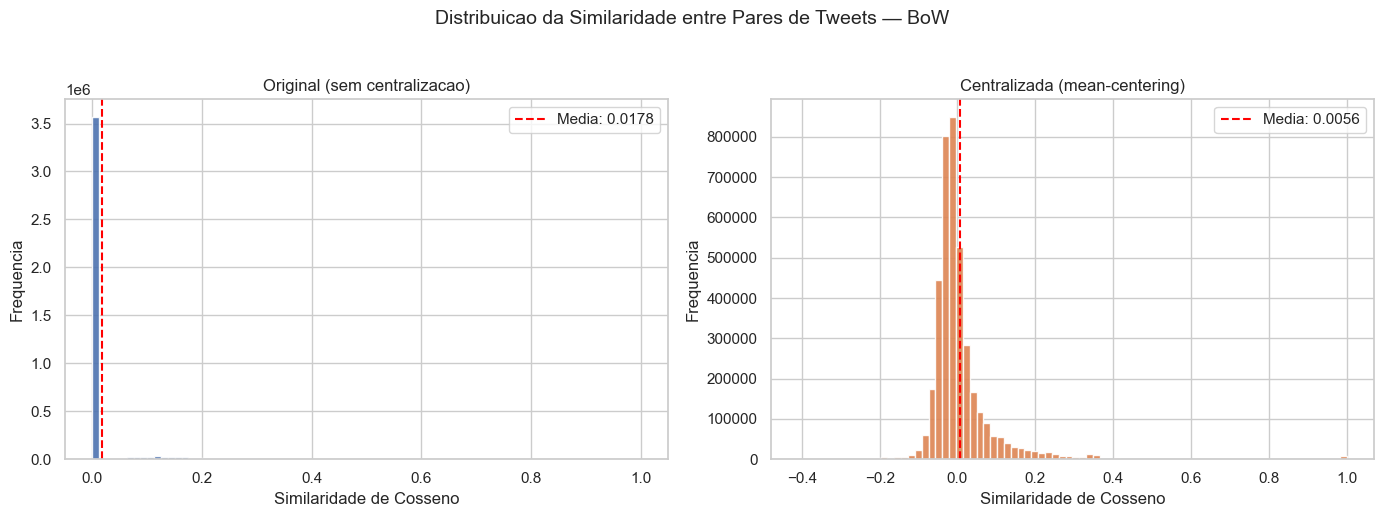

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Media: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralizacao)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Media: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequencia')
axes[1].legend()

plt.suptitle('Distribuicao da Similaridade entre Pares de Tweets — BoW', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## Heatmap de Similaridade Centralizada (Amostra)

Visualizamos uma amostra aleatória de tweets no heatmap. Com os vetores centralizados, as diferenças semânticas ficam visíveis: valores positivos indicam similaridade acima da média, valores negativos indicam dissimilaridade.

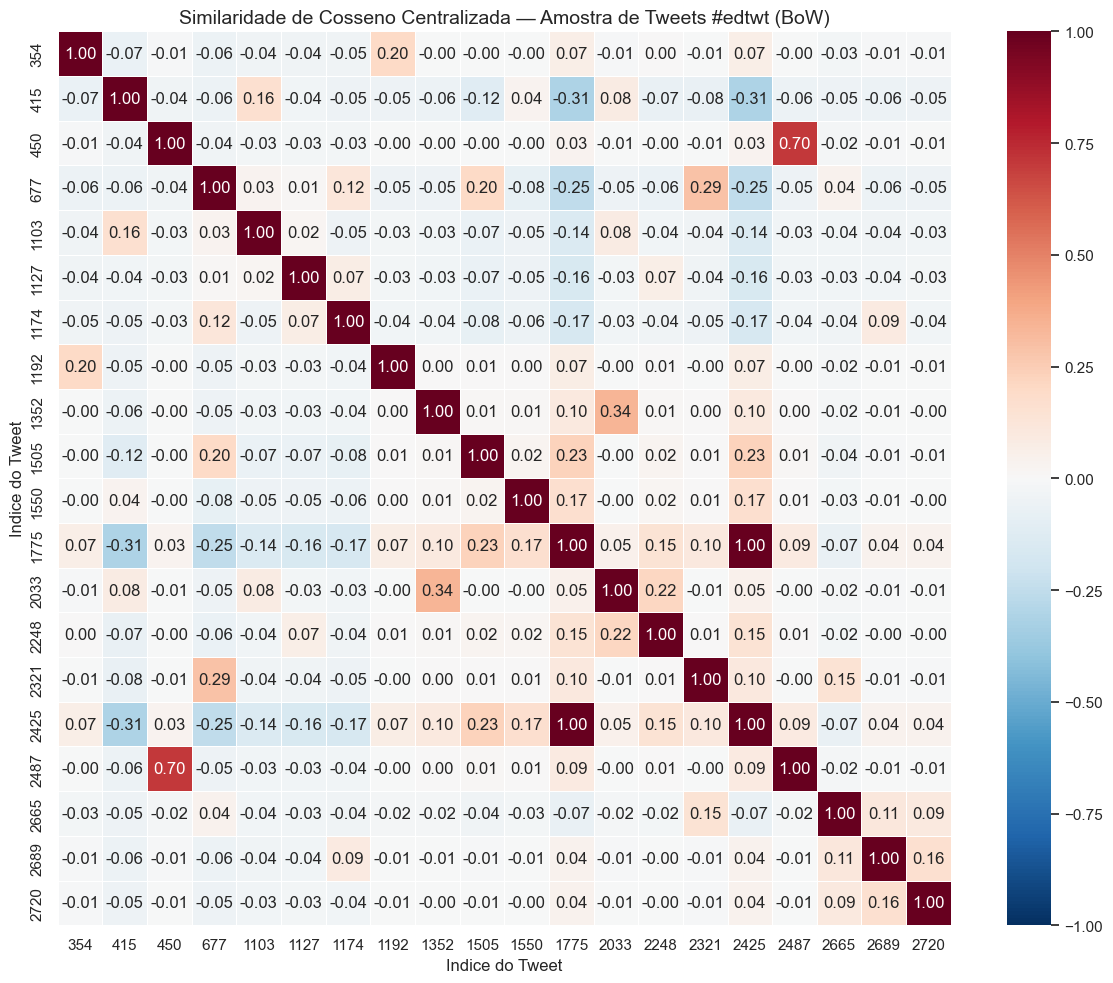

In [21]:
np.random.seed(seed)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno Centralizada — Amostra de Tweets #edtwt (BoW)', fontsize=14)
plt.xlabel('Indice do Tweet', fontsize=12)
plt.ylabel('Indice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
print('Tweets da amostra:\n')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

Tweets da amostra:

  [354] Fui me pesar e tô com 77 kg #fatspo #feederism #edtwt https://t.co/haFNW9k57M
  [415] uma pequena dica não óbvia para muitos, se você ainda come demais, quando vc ta comendo, v...
  [450] Busco mutis otra vez  arriba los edgys #shedtwt #edtwt #obstwt de todo menos pedotwt o zot...
  [677] dando uma de #edtwt pq eu to com mt fome pra jantar mas já passei as calorias do dia hoje ...
  [1103] quando eu pensar em comer vou pensar nela, tão bebezinha, pequena e delicada, a winter é m...
  [1127] Eu so vou conseguir mudar m8nha vida de verdade quando eu for magra, porquê existem duas v...
  [1174] amigos do #edtwt indicação de site pra vocês (se vcs não conhecerem) tem vaaaarias receita...
  [1192] é galera, eu oficialmente entrei na casa dos 70 quilos, eu tô muito feliz 😭😭😭🫶🫶🫶🎉🎉 #edtwt ...
  [1352] Café da manhã💗 ~94 kcal &gt;&lt; #edtwt https://t.co/sONafkX4Yh
  [1505] @ryanmaluco vai ter #edtwt hoje
  [1550] vomitei meu almoço, posso fazer parte do #edtwt e ser

## Agrupamento (Clustering) com KMeans

Aplicamos KMeans nos **vetores BoW centralizados** para agrupar os tweets em clusters temáticos. A centralização garante que o algoritmo identifique grupos baseados nas diferenças de frequência de termos, não no vocabulário comum compartilhado.

In [23]:
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=seed, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

Agrupamento com 3 clusters:

  Cluster 0 (3 tweets):
    - Necesito Mutis Necesito Mutis de #shtwt Necesito Mutis de #edtwt Necesito Mutis de #goretwt Necesito
    - Necesito mutis.#edtwt Necesito mutis.#shtwt Necesito mutis.#ORV Necesito mutis.#hsrtwt Necesito muti
    - Necesito mutis.#edtwt Necesito mutis.#shtwt Necesito mutis.#ORV Necesito mutis.#hsrtwt Necesito muti

  Cluster 1 (2790 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj

  Cluster 2 (22 tweets):
    - Uma mulher de 40 anos agindo como adolescente, antes do atestado, no final do plantão a faxineira se
    - Uma mulher de 40 anos agindo como adolescente, antes do atestado, no final do plantão a faxineira se
    - Uma mulher de 40 anos agindo como adolescente, a

## Visualização 2D com PCA e t-SNE

Reduzimos a dimensionalidade dos vetores BoW para 2D usando PCA (projeção linear que preserva variância) e t-SNE (projeção não-linear que preserva vizinhanças locais), permitindo visualizar a estrutura dos clusters.

In [24]:
pca_2d = PCA(n_components=2, random_state=seed)
vetores_pca = pca_2d.fit_transform(vetores_centralizados)

var_exp = pca_2d.explained_variance_ratio_
print(f'Variancia explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}')
print(f'Variancia total explicada (2 PCs): {var_exp.sum():.2%}')

plot_df_pca = pd.DataFrame({
    'PCA 1': vetores_pca[:, 0],
    'PCA 2': vetores_pca[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_pca = px.scatter(
    plot_df_pca, x='PCA 1', y='PCA 2', color='Cluster',
    title=f'PCA 2D: Clusters de Tweets #edtwt ({num_clusters} clusters) — BoW',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_pca.update_traces(marker=dict(size=4, opacity=0.7))
fig_pca.show()

Variancia explicada: PC1=3.19%, PC2=3.02%
Variancia total explicada (2 PCs): 6.20%


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity, max_iter=1000)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df_tsne = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_tsne = px.scatter(
    plot_df_tsne, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters de Tweets #edtwt ({num_clusters} clusters) — BoW',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_tsne.update_traces(marker=dict(size=4, opacity=0.7))
fig_tsne.show()

## Visualização 3D com PCA

Projeção em três componentes principais para explorar a estrutura dos clusters no espaço tridimensional.

In [ ]:
pca_3d = PCA(n_components=3, random_state=seed)
vetores_pca3 = pca_3d.fit_transform(vetores_centralizados)

var_exp3 = pca_3d.explained_variance_ratio_
print(f'Variancia explicada: PC1={var_exp3[0]:.2%}, PC2={var_exp3[1]:.2%}, PC3={var_exp3[2]:.2%}')
print(f'Variancia total explicada (3 PCs): {var_exp3.sum():.2%}')

pca3_df = pd.DataFrame({
    'PCA 1': vetores_pca3[:, 0],
    'PCA 2': vetores_pca3[:, 1],
    'PCA 3': vetores_pca3[:, 2],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_3d = px.scatter_3d(
    pca3_df,
    x='PCA 1', y='PCA 2', z='PCA 3',
    color='Cluster',
    title=f'PCA 3D: Clusters de Tweets #edtwt ({num_clusters} clusters) — BoW',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'PCA 3': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_3d.update_traces(marker=dict(size=3, opacity=0.7))
fig_3d.show()

## Comparação: BoW vs. TF-IDF

Comparamos as matrizes de similaridade do BoW e TF-IDF sobre o mesmo subconjunto de tweets.

- **BoW**: frequência bruta de termos, sem ponderação.
- **TF-IDF**: ponderação que penaliza termos frequentes em muitos documentos (como "edtwt") e valoriza termos discriminativos.

Ambos os conjuntos de vetores são centralizados pela média antes da comparação.

In [ ]:
def parse_features_tfidf(feature_str):
    if pd.isna(feature_str):
        return {}
    try:
        return ast.literal_eval(feature_str)
    except (ValueError, SyntaxError):
        return {}

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        tfidf_config = json.load(f)
    nomes_features = tfidf_config.get('feature_names', [])

    dicts_tfidf = df['features_tfidf_sklearn'].apply(parse_features_tfidf)

    vetores_tfidf = np.zeros((len(df), len(nomes_features)), dtype=np.float32)
    for i, d in enumerate(dicts_tfidf):
        for idx_f, feat_name in enumerate(nomes_features):
            vetores_tfidf[i, idx_f] = d.get(feat_name, 0.0)

    np.random.seed(seed)
    n_comp = min(200, len(vetores_tfidf))
    idx_comp = np.sort(np.random.choice(len(vetores_tfidf), size=n_comp, replace=False))

    bow_sample = vetores_bow[idx_comp]
    tfidf_sample = vetores_tfidf[idx_comp]

    bow_sample_cent = bow_sample - bow_sample.mean(axis=0)
    tfidf_sample_cent = tfidf_sample - tfidf_sample.mean(axis=0)

    sim_bow = cosine_similarity(bow_sample_cent)
    sim_tfidf = cosine_similarity(tfidf_sample_cent)

    bow_upper = sim_bow[np.triu_indices_from(sim_bow, k=1)]
    tfidf_upper = sim_tfidf[np.triu_indices_from(sim_tfidf, k=1)]

    print(f'BoW (centralizado):    media={bow_upper.mean():.4f}, std={bow_upper.std():.4f}')
    print(f'TF-IDF (centralizado): media={tfidf_upper.mean():.4f}, std={tfidf_upper.std():.4f}')
    print(f'Correlacao entre matrizes: {np.corrcoef(sim_bow.flatten(), sim_tfidf.flatten())[0,1]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.heatmap(sim_bow, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[0])
    axes[0].set_title('BoW — Similaridade Centralizada', fontsize=12)
    sns.heatmap(sim_tfidf, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[1])
    axes[1].set_title('TF-IDF — Similaridade Centralizada', fontsize=12)
    plt.suptitle('Comparacao BoW vs. TF-IDF (200 tweets)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f'Arquivo de metadados TF-IDF nao encontrado: {json_path}')
    print('Execute a entrega 2 antes para gerar os dados necessarios.')

## Observações

- O BoW é uma representação **esparsa** — cada documento ativa apenas os termos que contém.
- Sem ponderação, termos muito frequentes (ex: "edtwt", "não") dominam a similaridade.
- A centralização pela média é essencial para revelar diferenças entre documentos.
- Comparado ao TF-IDF, o BoW tende a gerar clusters menos coesos, pois não penaliza termos genéricos.